<a href="https://colab.research.google.com/github/GusthavoSoares/tech_challenge_data_analytics/blob/main/Analise_Receita_Olist_TechChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#Importando dataset
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

#Pergunta de Negócio: Qual categoria de produto teve maior valor de receita acumulado no período. Das top 5 categorias, qual teve maior crescimento de receita no período.

#Preparando o dataframe para análise  
Para a resposta da pergunta e uma análise mais aprofundada, utilizaremos algumas colunas de cada tabela para gerar um dataframe novo em cima do qual a análise será feita.

In [ ]:
#Verificação das tabelas disponíveis no dataset
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


De 'customers', serão utilizadas as colunas 'costumer_id', 'customer_city' e 'customer_state'

In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


De 'orders' serão utilizadas as colunas 'order_id, 'customer_id', 'order_status' e 'order_approved_at'. Na análise serão consideradas apenas pedidos com o status 'entregue' e a data de compra como referência será a que o pedido foi aprovado.

In [ ]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


De 'order_items' serão utilizadas as colunas 'order_id', 'product_id', 'price' e 'freight_value'. A receita dos pedidos será considerada a soma entre o preço do produto e o frete do pedido.

In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


De 'products' serão utilizadas as colunas 'product_id' e 'procut_category_name'. Dessa forma iremos definir qual a categoria com maior receita e crescimento no período

In [ ]:
#Criação das tabelas principais para análise, considerando colunas selecionadas anteriormente e filtros

#1. Merge orders e customers utilizando 'customer_id'
df_analise = pd.merge(
    orders[['order_id', 'customer_id', 'order_status', 'order_approved_at', 'order_delivered_customer_date']],
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='inner'
)

#2. Merge df_analise e order_items utilizando 'order_id'
df_analise = pd.merge(
    df_analise,
    order_items[['order_id', 'product_id', 'price', 'freight_value']],
    on='order_id',
    how='inner'
)

#3. Merge df_analise e products utilizando 'product_id'
df_analise = pd.merge(
    df_analise,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

#Aplicando o filtro apenas para analisarmos pedidos entregues
df_analise = df_analise[df_analise['order_status'] == 'delivered']

#Conversão de colunas de data para datetime
df_analise['order_approved_at'] = pd.to_datetime(df_analise['order_approved_at'])
df_analise['order_delivered_customer_date'] = pd.to_datetime(df_analise['order_delivered_customer_date'])

#Definindo as colunas princpiais para tratamento de valores nulos
colunas_principais = ['customer_id', 'customer_city', 'customer_state', 'order_id', 'order_approved_at', 'order_delivered_customer_date', 'product_id', 'product_category_name', 'price', 'freight_value']
df_analise.dropna(subset = colunas_principais, inplace = True)
df_analise.reset_index(drop = True, inplace = True)

#Definição final de df_analise
df_analise = df_analise[colunas_principais]

#Definição de df_produtos com a coluna 'receita' sendo a soma do preço e frete
df_produtos = df_analise[['customer_id', 'customer_city', 'customer_state', 'order_id', 'product_id', 'product_category_name', 'price', 'freight_value', 'order_approved_at', 'order_delivered_customer_date']].copy()
df_produtos['receita'] = df_produtos['price'] + df_produtos['freight_value']

In [ ]:
#Verificação de df_analise
df_analise.head()

,customer_id,customer_city,customer_state,order_id,order_approved_at,order_delivered_customer_date,product_id,product_category_name,price,freight_value
0,9ef432eb6251297304e76186b10a928d,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 11:07:15,2017-10-10 21:25:13,87285b34884572647811a353c7ac498a,utilidades_domesticas,29.99,8.72
1,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,2018-07-26 03:24:27,2018-08-07 15:27:45,595fac2a385ac33a80bd5114aec74eb8,perfumaria,118.70,22.76
2,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:55:23,2018-08-17 18:06:29,aa4383b373c6aca5d8797843e5594415,automotivo,159.90,19.22
3,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:45:59,2017-12-02 00:28:42,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20
4,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 22:20:29,2018-02-16 18:17:02,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,19.90,8.72


In [ ]:
df_analise.isna().sum()

,0
customer_id,0
customer_city,0
customer_state,0
order_id,0
order_approved_at,0
order_delivered_customer_date,0
product_id,0
product_category_name,0
price,0
freight_value,0


In [ ]:
df_analise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108638 entries, 0 to 108637
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    108638 non-null  object        
 1   customer_city                  108638 non-null  object        
 2   customer_state                 108638 non-null  object        
 3   order_id                       108638 non-null  object        
 4   order_approved_at              108638 non-null  datetime64[ns]
 5   order_delivered_customer_date  108638 non-null  datetime64[ns]
 6   product_id                     108638 non-null  object        
 7   product_category_name          108638 non-null  object        
 8   price                          108638 non-null  float64       
 9   freight_value                  108638 non-null  float64       
dtypes: datetime64[ns](2), float64(2), object(6)
memory usage: 8.3+ MB


In [ ]:
#Verificação de df_produtos
df_produtos.head()

,customer_id,customer_city,customer_state,order_id,product_id,product_category_name,price,freight_value,order_approved_at,order_delivered_customer_date,receita
0,9ef432eb6251297304e76186b10a928d,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,utilidades_domesticas,29.99,8.72,2017-10-02 11:07:15,2017-10-10 21:25:13,38.71
1,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,perfumaria,118.70,22.76,2018-07-26 03:24:27,2018-08-07 15:27:45,141.46
2,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,automotivo,159.90,19.22,2018-08-08 08:55:23,2018-08-17 18:06:29,179.12
3,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20,2017-11-18 19:45:59,2017-12-02 00:28:42,72.20
4,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,19.90,8.72,2018-02-13 22:20:29,2018-02-16 18:17:02,28.62


In [ ]:
df_produtos.isna().sum()

,0
customer_id,0
customer_city,0
customer_state,0
order_id,0
product_id,0
product_category_name,0
price,0
freight_value,0
order_approved_at,0
order_delivered_customer_date,0


In [ ]:
df_produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108638 entries, 0 to 108637
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    108638 non-null  object        
 1   customer_city                  108638 non-null  object        
 2   customer_state                 108638 non-null  object        
 3   order_id                       108638 non-null  object        
 4   product_id                     108638 non-null  object        
 5   product_category_name          108638 non-null  object        
 6   price                          108638 non-null  float64       
 7   freight_value                  108638 non-null  float64       
 8   order_approved_at              108638 non-null  datetime64[ns]
 9   order_delivered_customer_date  108638 non-null  datetime64[ns]
 10  receita                        108638 non-null  float64       
dtype

#Início da Análise, definição das 5 categorias com maior receita no período

In [ ]:
top5_categorias = df_produtos.groupby('product_category_name')['receita'].sum().sort_values(ascending=False).head(5).index.tolist()
top5_categorias

['beleza_saude',
 'relogios_presentes',
 'cama_mesa_banho',
 'esporte_lazer',
 'informatica_acessorios']

In [ ]:
#Criação de tabela com as top 5 categorias e agrupando as receita das categorias por mês
df_top5_produtos = df_produtos[df_produtos['product_category_name'].isin(top5_categorias)].copy()
df_top5_produtos['mes'] = df_top5_produtos['order_approved_at'].dt.to_period('M').dt.start_time
receita_mensal_por_categoria = df_top5_produtos.groupby(['product_category_name', 'mes'])['receita'].sum().reset_index()
receita_mensal_por_categoria.head()

,product_category_name,mes,receita
0,beleza_saude,2016-09-01,143.46
1,beleza_saude,2016-10-01,4186.29
2,beleza_saude,2017-01-01,11883.11
3,beleza_saude,2017-02-01,26961.82
4,beleza_saude,2017-03-01,29509.34


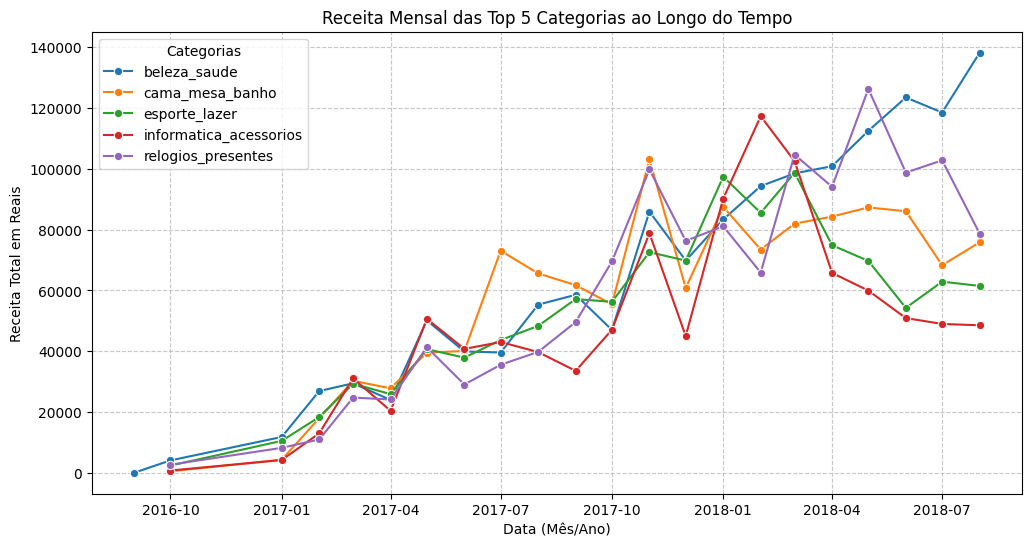

In [ ]:
#Visualização da Receita Mensal das Top 5 Categorias ao longo do tempo
plt.figure(figsize=(12,6))
sns.lineplot(data=receita_mensal_por_categoria, x='mes', y='receita', hue='product_category_name', marker='o')
plt.title('Receita Mensal das Top 5 Categorias ao Longo do Tempo')
plt.xlabel('Data (Mês/Ano)')
plt.ylabel('Receita Total em Reais')
plt.xticks(rotation=0)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title='Categorias')
plt.show()

Como apenas a categoria 'beleza_saude' tem dados de antes de outbro de 2016 e não temos dados dos meses de novembro e dezembro de 2016, adotaremos um novo filtro considerando a partir de janeiro de 2017

In [ ]:
#Filtrando os dados a partir de janeiro de 2017 para garantir dados consistentes para todas as categorias
receita_mensal_por_categoria_filtrada = receita_mensal_por_categoria[receita_mensal_por_categoria['mes'] >= '2017-01-01'].copy()


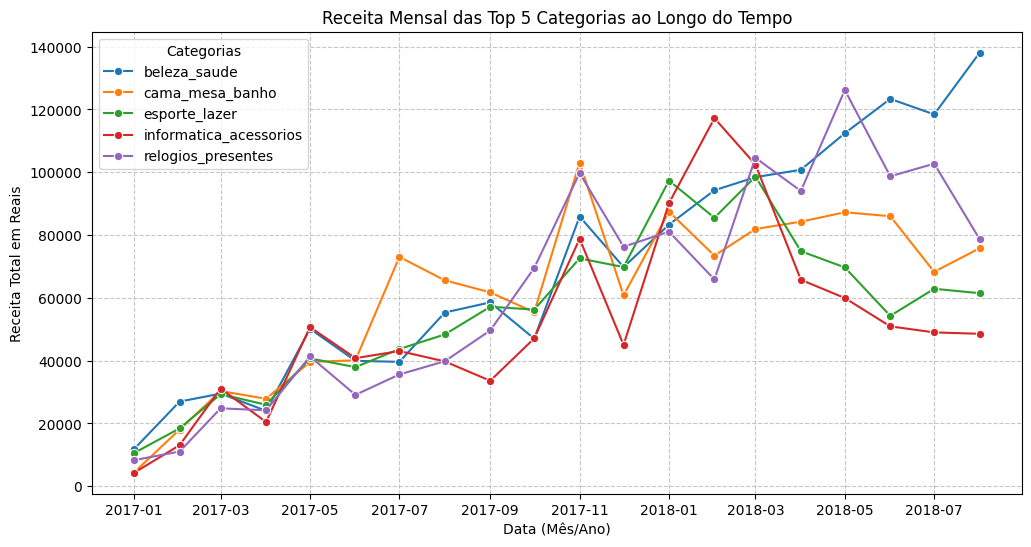

In [ ]:
#Visualização da Receita Mensal das Top 5 Categorias ao longo do tempo (Jan/17 - Ago/18)
plt.figure(figsize=(12,6))
sns.lineplot(data=receita_mensal_por_categoria_filtrada, x='mes', y='receita', hue='product_category_name', marker='o')
plt.title('Receita Mensal das Top 5 Categorias ao Longo do Tempo')
plt.xlabel('Data (Mês/Ano)')
plt.ylabel('Receita Total em Reais')
plt.xticks(rotation=0)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title='Categorias')
plt.show()

No gráfico acima é possível ver o corportamento mês a mês das receitas das categorias, a partir da análise abaixo, validaremos qual categoria teve maior crescimento de receita dentro do período (Jan/17 - Ago/18)

In [ ]:
#Cálculo da receita para o primeiro e o último mês de cada categoria
receita_por_categoria = receita_mensal_por_categoria_filtrada.groupby('product_category_name').agg(
    receita_primeiro_mes  = ('receita', 'first'),
    receita_ultimo_mes = ('receita', 'last')
).reset_index()

#Função para calcular a porcentagem de crescimento
def percentual_crescimento_receita_mensal(linha):
  if linha['receita_primeiro_mes'] != 0:
    return ((linha['receita_ultimo_mes'] - linha['receita_primeiro_mes']) / linha['receita_primeiro_mes']) * 100
  else:
    return 0

#Aplicando a função para calcular a porcentagem de crescimento
receita_por_categoria['percentual_de_crescimento'] = receita_por_categoria.apply(percentual_crescimento_receita_mensal, axis=1)

receita_por_categoria.sort_values(by='percentual_de_crescimento', ascending = False)

,product_category_name,receita_primeiro_mes,receita_ultimo_mes,percentual_de_crescimento
1,cama_mesa_banho,4417.21,75800.75,1616.032292
0,beleza_saude,11883.11,138058.44,1061.803939
3,informatica_acessorios,4313.95,48556.15,1025.561261
4,relogios_presentes,8310.83,78680.09,846.717596
2,esporte_lazer,10604.85,61484.96,479.781515


Com a tabela acima, temos que a categoria que teve um maior crescimento de receita no período foi 'cama_mesa_banho' seguida por 'beleza_saude' e 'informatica_acessorios'. Mesmo com beleza saúde tendo a maior receita acumulada no período, conforme visto na tabela abaixo:

In [ ]:
#Verificação da receita total por categoria
receita_mensal_por_categoria_filtrada.groupby('product_category_name')['receita'].sum().sort_values(ascending=False).reset_index()

,product_category_name,receita
0,beleza_saude,1407759.78
1,relogios_presentes,1261223.27
2,cama_mesa_banho,1224445.49
3,esporte_lazer,1115477.69
4,informatica_acessorios,1031741.81


In [ ]:
receita_total_por_categoria = receita_mensal_por_categoria_filtrada.groupby('product_category_name')['receita'].sum().reset_index()
receita_total_por_categoria.rename(columns={'receita': 'receita_total_acumulada'}, inplace=True)

tabela_crescimento_e_receita = pd.merge(
    receita_por_categoria,
    receita_total_por_categoria,
    on='product_category_name',
    how='inner'
)

tabela_crescimento_e_receita.sort_values(by='percentual_de_crescimento', ascending=False).round(2)

,product_category_name,receita_primeiro_mes,receita_ultimo_mes,percentual_de_crescimento,receita_total_acumulada
1,cama_mesa_banho,4417.21,75800.75,1616.03,1224445.49
0,beleza_saude,11883.11,138058.44,1061.80,1407759.78
3,informatica_acessorios,4313.95,48556.15,1025.56,1031741.81
4,relogios_presentes,8310.83,78680.09,846.72,1261223.27
2,esporte_lazer,10604.85,61484.96,479.78,1115477.69


Análise da Receita e Crescimento das Principais Categorias - Categorias se dividem entre consolidadas (alto volume) e em expansão (alto crescimento). A estratégia deve equilibrar manutenção das líderes e investimento nas categorias com maior potencial de crescimento.

### Top 3 Categorias por Estado



In [ ]:
# Agrupa os dados por estado do cliente e nome da categoria do produto, somando a receita para cada combinação.
receita_por_estado_categoria = df_produtos.groupby(['customer_state', 'product_category_name'])['receita'].sum().reset_index()

# Para cada estado, seleciona as 3 categorias com a maior receita (Top 3).
top3_categorias_por_estado = receita_por_estado_categoria.groupby('customer_state').apply(
    lambda x: x.nlargest(3, 'receita')
).reset_index(drop=True)

top3_categorias_por_estado

/tmp/ipykernel_13503/308985886.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_categorias_por_estado = receita_por_estado_categoria.groupby('customer_state').apply(


,customer_state,product_category_name,receita
0,AC,esporte_lazer,2071.54
1,AC,moveis_decoracao,1746.70
2,AC,beleza_saude,1655.00
3,AL,beleza_saude,14741.33
4,AL,relogios_presentes,12650.16
...,...,...,...
76,SP,beleza_saude,510255.38
77,SP,relogios_presentes,448266.62
78,TO,esporte_lazer,6454.31
79,TO,beleza_saude,6026.33


In [ ]:
#Criação da tabela com frequencia das categorias nos top 3 de cada estado
tabela_longa_top3 = top3_categorias_por_estado.copy()

# Adiciona a coluna 'rank' ao DataFrame, classificando a receita dentro de cada estado
tabela_longa_top3['rank'] = tabela_longa_top3.groupby('customer_state')['receita'].rank(method='first', ascending=False).astype(int)

# Transforma o rank numérico para o formato de string 'Top 1', 'Top 2', 'Top 3'
tabela_longa_top3['rank'] = tabela_longa_top3['rank'].map({1: 'Top 1', 2: 'Top 2', 3: 'Top 3'})

# Contando a frequência de cada categoria em cada posição (Top 1, Top 2, Top 3).
contagem_por_categoria_rank = tabela_longa_top3.groupby(['product_category_name', 'rank']).size().unstack(fill_value=0)

contagem_por_categoria_rank.sort_values(by=['Top 1', 'Top 2', 'Top 3'], ascending=False)

rank,Top 1,Top 2,Top 3
product_category_name,,,
beleza_saude,15,5,4
esporte_lazer,5,0,5
relogios_presentes,4,11,5
cama_mesa_banho,2,3,1
informatica_acessorios,1,2,6
moveis_decoracao,0,2,1
automotivo,0,1,2
cool_stuff,0,1,0
eletrodomesticos,0,1,0


### Recalculando o Ticket Médio para Categorias que Aparecem no Top 3 por Estado

In [ ]:
#Obter a lista de todas as categorias que aparecem no Top 3 de qualquer estado
categorias_top3_por_estado = tabela_longa_top3['product_category_name'].unique().tolist()

#Filtrar o DataFrame original de produtos para incluir apenas essas categorias
df_categorias_top3_estados = df_produtos[df_produtos['product_category_name'].isin(categorias_top3_por_estado)].copy()

#Calcular o ticket médio (receita total / número de pedidos únicos) por categoria para essas categorias
# A média da receita por item já é o 'ticket médio' por item.
ticket_medio_top3_estados = df_categorias_top3_estados.groupby('product_category_name')['receita'].mean().sort_values(ascending=False).reset_index().round(2)
ticket_medio_top3_estados.rename(columns={'receita': 'ticket_medio'}, inplace=True)

ticket_medio_top3_estados

,product_category_name,ticket_medio
0,relogios_presentes,215.81
1,cool_stuff,186.10
2,automotivo,161.71
3,bebes,156.51
4,beleza_saude,149.19
5,informatica_acessorios,135.10
6,ferramentas_jardim,132.88
7,esporte_lazer,132.65
8,eletrodomesticos,123.74
9,cama_mesa_banho,111.86


### Combinando Contagem de Rank e o NOVO Ticket Médio por Categoria

In [ ]:
# Resetando o índice de contagem_por_categoria_rank para transformar 'product_category_name' em uma coluna
contagem_por_categoria_rank_reset = contagem_por_categoria_rank.reset_index()

# Combinando as duas tabelas com base na coluna 'product_category_name'
tabela_final_combinada_nova = pd.merge(
    contagem_por_categoria_rank_reset,
    ticket_medio_top3_estados,
    on='product_category_name',
    how='left' # Usar left join para manter todas as categorias da tabela de contagem
)

tabela_final_combinada_nova.sort_values(by='ticket_medio', ascending=False)

,product_category_name,Top 1,Top 2,Top 3,ticket_medio
10,relogios_presentes,4,11,5,215.81
4,cool_stuff,0,1,0,186.10
0,automotivo,0,1,2,161.71
1,bebes,0,0,1,156.51
2,beleza_saude,15,5,4,149.19
8,informatica_acessorios,1,2,6,135.10
7,ferramentas_jardim,0,0,1,132.88
6,esporte_lazer,5,0,5,132.65
5,eletrodomesticos,0,1,0,123.74
3,cama_mesa_banho,2,3,1,111.86


Se considerarmos o top5 ticket médio, as categorias 'automotivo' e 'bebes' são casos especificos em que são condicionados a ter um carro ou um filho, a categoria 'beleza_saude' já desempenha bem quando consideramos numero de venda e receita. Então, podemos avaliar as duas primeiras categorias, 'relogios_presentes' e 'cool_stuff', que possuem os maiores ticket médios mas não estão tão presentes como prioridade em todos os estados.

### Estados onde 'relogios_presentes' e 'cool_stuff' não estão no Top 3


In [ ]:
# Obter todos os estados únicos
todos_estados = df_produtos['customer_state'].unique()

# Estados onde 'relogios_presentes' está no Top 3
estados_com_relogios_top3 = top3_categorias_por_estado[top3_categorias_por_estado['product_category_name'] == 'relogios_presentes']['customer_state'].unique()

# Estados onde 'cool_stuff' está no Top 3
estados_com_cool_stuff_top3 = top3_categorias_por_estado[top3_categorias_por_estado['product_category_name'] == 'cool_stuff']['customer_state'].unique()

# Estados onde 'relogios_presentes' NÃO está no Top 3
estados_sem_relogios_top3 = set(todos_estados) - set(estados_com_relogios_top3)

# Estados onde 'cool_stuff' NÃO está no Top 3
estados_sem_cool_stuff_top3 = set(todos_estados) - set(estados_com_cool_stuff_top3)

# Estados onde 'relogios_presentes' NÃO está no Top 3 E 'cool_stuff' NÃO está no Top 3
estados_potenciais = list(estados_sem_relogios_top3.intersection(estados_sem_cool_stuff_top3))

estados_potenciais

['MS', 'RR', 'SC', 'RS', 'AM', 'AC']

Ticket Médio e Distribuição Geográfica - As principais oportunidades estão em categorias com alto ticket médio e baixa presença regional. A ativação deve focar em campanhas direcionadas e incentivos à conversão nesses mercados.

### Análise de Notas dos Pedidos por Categoria de Produto


In [ ]:
#Unir df_produtos com order_reviews para obter as notas
df_com_reviews = pd.merge(
    df_produtos,
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

#Calcular a nota média e a quantidade de pedidos por categoria de produto
notas_medias_por_categoria = df_com_reviews.groupby('product_category_name').agg(
    nota_media=('review_score', 'mean'),
    quantidade_pedidos=('order_id', 'size')
).sort_values(by='nota_media', ascending=False).reset_index().round(2)

notas_medias_por_categoria.head(10)

,product_category_name,nota_media,quantidade_pedidos
0,fashion_roupa_infanto_juvenil,5.00,7
1,cds_dvds_musicais,4.64,14
2,livros_interesse_geral,4.51,536
3,livros_importados,4.51,57
4,construcao_ferramentas_ferramentas,4.44,103
5,portateis_casa_forno_e_cafe,4.44,73
6,flores,4.42,33
7,livros_tecnicos,4.39,265
8,alimentos_bebidas,4.37,271
9,fashion_esporte,4.37,30


Considerar apenas categorias com mais de 100 pedidos para termos uma base maior no cálculo da média de nota.

In [ ]:
notas_medias_filtradas = notas_medias_por_categoria[notas_medias_por_categoria['quantidade_pedidos'] >= 100].round(2)
notas_medias_filtradas.sort_values(by='nota_media', ascending=False).head(10)

,product_category_name,nota_media,quantidade_pedidos
2,livros_interesse_geral,4.51,536
4,construcao_ferramentas_ferramentas,4.44,103
7,livros_tecnicos,4.39,265
8,alimentos_bebidas,4.37,271
10,malas_acessorios,4.35,1077
12,fashion_calcados,4.29,260
13,alimentos,4.26,499
14,moveis_quarto,4.25,103
15,papelaria,4.24,2474
16,eletroportateis,4.23,661


In [ ]:
#Obter a lista de categorias de 'notas_medias_filtradas'
categorias_com_alta_nota = notas_medias_filtradas['product_category_name'].tolist()

#Filtrar o DataFrame original df_produtos para incluir apenas essas categorias
df_categorias_filtradas = df_produtos[df_produtos['product_category_name'].isin(categorias_com_alta_nota)].copy()

#Calcular o ticket médio (receita total / número de pedidos únicos) por categoria para essas categorias
ticket_medio_categorias_filtradas = df_categorias_filtradas.groupby('product_category_name')['receita'].mean().sort_values(ascending=False).reset_index()
ticket_medio_categorias_filtradas.rename(columns={'receita': 'ticket_medio_medio'}, inplace=True)

ticket_medio_categorias_filtradas

,product_category_name,ticket_medio_medio
0,pcs,1147.486231
1,eletrodomesticos_2,511.725195
2,agro_industria_e_comercio,369.918932
3,instrumentos_musicais,310.579293
4,eletroportateis,301.003744
5,telefonia_fixa,234.574667
6,construcao_ferramentas_seguranca,231.358022
7,moveis_quarto,226.982718
8,relogios_presentes,215.813041
9,moveis_cozinha_area_de_servico_jantar_e_jardim,208.295511


In [ ]:
# Combinando as tabelas
tabela_final_qualidade_e_ticket = pd.merge(
    notas_medias_filtradas,
    ticket_medio_categorias_filtradas,
    on='product_category_name',
    how='left'
)

tabela_final_qualidade_e_ticket.sort_values(by='ticket_medio_medio', ascending=False).head(10).round(2)

,product_category_name,nota_media,quantidade_pedidos,ticket_medio_medio
12,pcs,4.22,199,1147.49
20,eletrodomesticos_2,4.16,233,511.73
29,agro_industria_e_comercio,4.09,206,369.92
11,instrumentos_musicais,4.22,652,310.58
9,eletroportateis,4.23,661,301.00
50,telefonia_fixa,3.76,256,234.57
43,construcao_ferramentas_seguranca,3.96,182,231.36
7,moveis_quarto,4.25,103,226.98
35,relogios_presentes,4.07,5867,215.81
40,moveis_cozinha_area_de_servico_jantar_e_jardim,4.03,274,208.30


Avaliação dos Produtos e Potencial de Escala - Produtos com alta avaliação e bom volume indicam potencial de receita ainda não explorado. Estratégias devem focar em aumentar visibilidade e conversão, aproveitando a prova social.